Task 4 — Full EDA on a housing dataset 

Run a complete exploratory analysis on California Housing Prices from Kaggle. It is a housing 
dataset based on 1990 California census data.  
Dataset reference: California Housing Prices on Kaggle. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
print("[INFO] Fetching California Housing dataset...")
california = fetch_california_housing(as_frame=True)
df = california.frame

[INFO] Fetching California Housing dataset...


In [3]:
df = df.rename(columns={'MedHouseVal': 'MedHouseVal_hundred_k'})

print("\n--- Dataset Overview ---")
print(f"Shape: {df.shape}")
print("\nFirst 5 Rows:")
print(df.head())


--- Dataset Overview ---
Shape: (20640, 9)

First 5 Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal_hundred_k  
0    -122.23                  4.526  
1    -122.22                  3.585  
2    -122.24                  3.521  
3    -122.25                  3.413  
4    -122.25                  3.422  


In [4]:
print("\n--- Missing Values Check ---")
print(df.isnull().sum())

print("\n--- Descriptive Statistics ---")
print(df.describe().T)


--- Missing Values Check ---
MedInc                   0
HouseAge                 0
AveRooms                 0
AveBedrms                0
Population               0
AveOccup                 0
Latitude                 0
Longitude                0
MedHouseVal_hundred_k    0
dtype: int64

--- Descriptive Statistics ---
                         count         mean          std         min  \
MedInc                 20640.0     3.870671     1.899822    0.499900   
HouseAge               20640.0    28.639486    12.585558    1.000000   
AveRooms               20640.0     5.429000     2.474173    0.846154   
AveBedrms              20640.0     1.096675     0.473911    0.333333   
Population             20640.0  1425.476744  1132.462122    3.000000   
AveOccup               20640.0     3.070655    10.386050    0.692308   
Latitude               20640.0    35.631861     2.135952   32.540000   
Longitude              20640.0  -119.569704     2.003532 -124.350000   
MedHouseVal_hundred_k  20640.0    

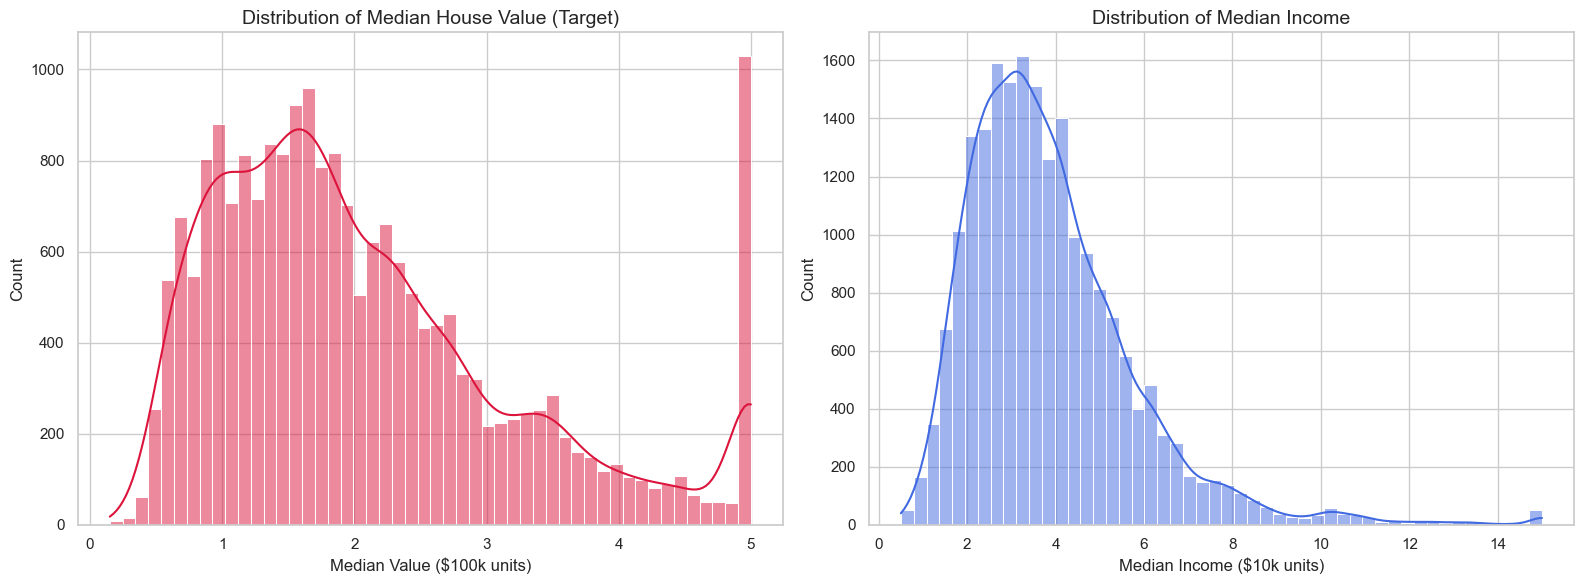

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['MedHouseVal_hundred_k'], bins=50, kde=True, color='crimson', ax=ax1)
ax1.set_title('Distribution of Median House Value (Target)', fontsize=14)
ax1.set_xlabel('Median Value ($100k units)', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)

sns.histplot(df['MedInc'], bins=50, kde=True, color='royalblue', ax=ax2)
ax2.set_title('Distribution of Median Income', fontsize=14)
ax2.set_xlabel('Median Income ($10k units)', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)

plt.tight_layout()
display(fig)
plt.close()

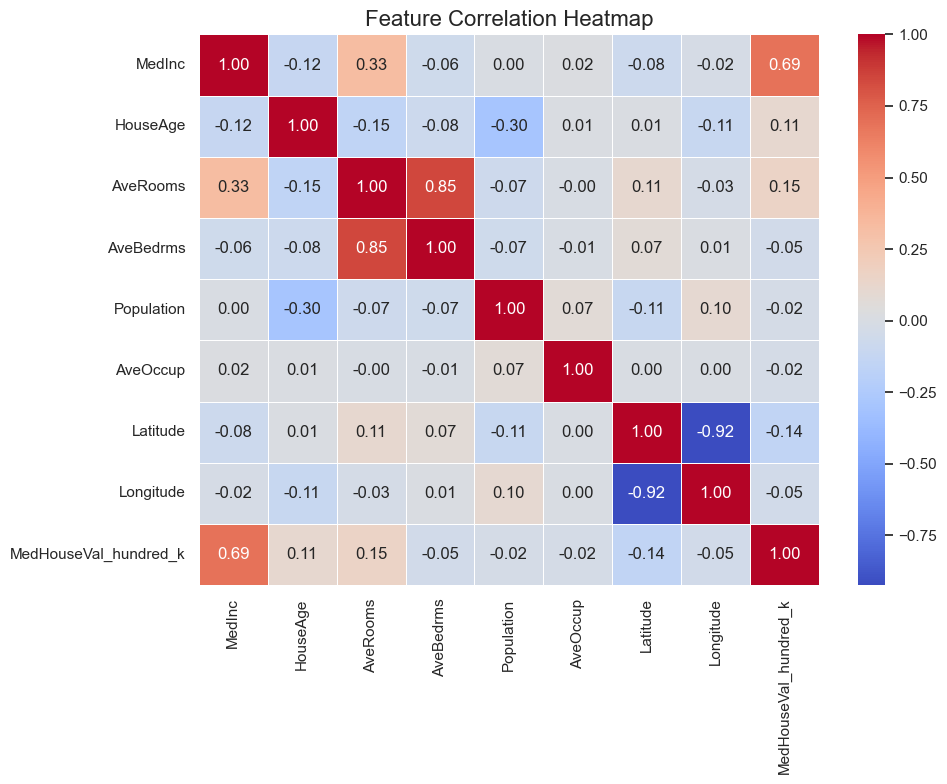

In [6]:
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
display(plt.gcf())
plt.close()

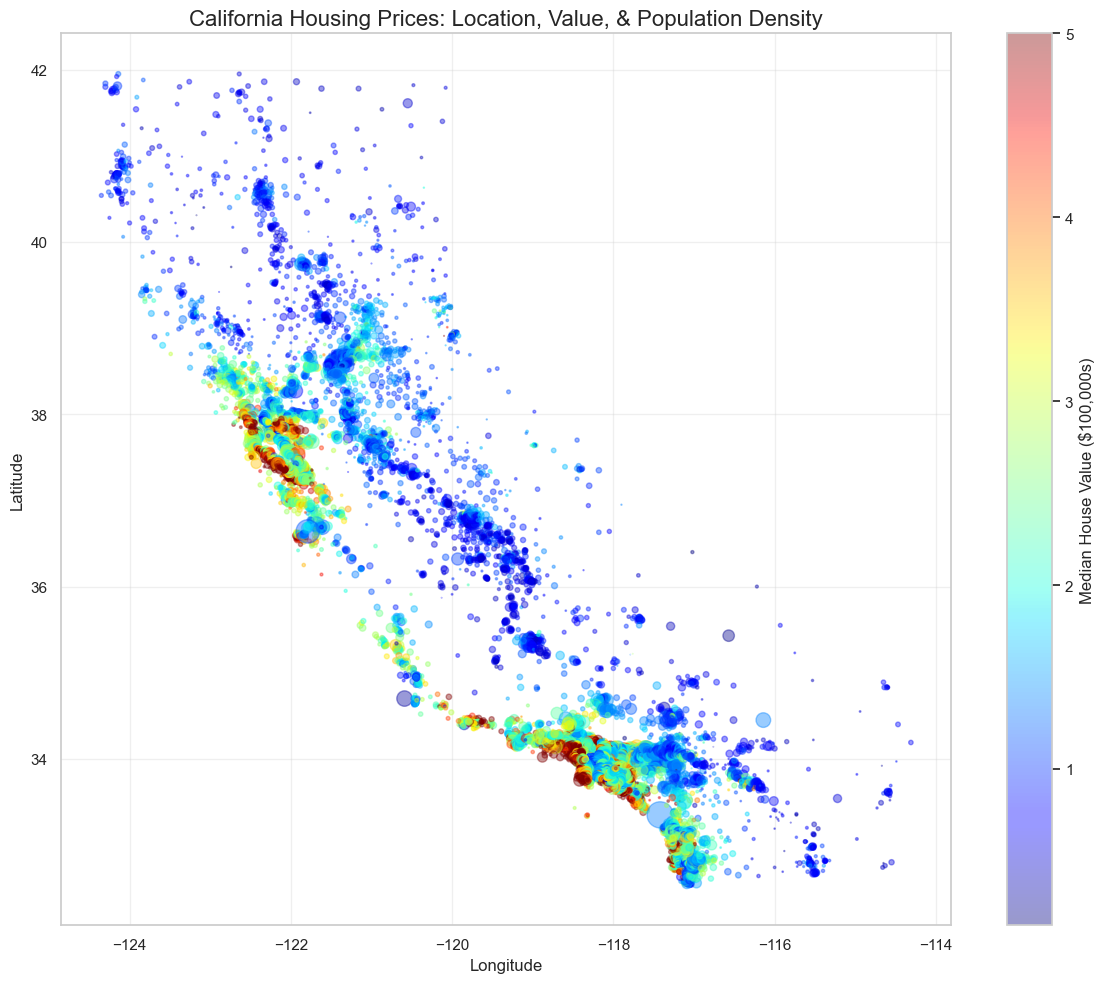

In [9]:
plt.figure(figsize=(12, 10))
sc = plt.scatter(
    df['Longitude'], 
    df['Latitude'], 
    alpha=0.4,
    s=df['Population'] / 100,
    c=df['MedHouseVal_hundred_k'],
    cmap=plt.get_cmap('jet'), 
    label='Population'
)
plt.colorbar(sc, label='Median House Value ($100,000s)')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title('California Housing Prices: Location, Value, & Population Density', fontsize=16)
plt.grid(True, alpha=0.3)

plt.tight_layout()
display(plt.gcf())
plt.close()